In [15]:
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt 

a = 0.0
b = 1.0
lambda_0 = 0.5
epsilon = 1e-3
h = 0.05 

def y(t):
    return np.full_like(t, -5.0)

def kernel(t, s):
    return -5.0 * t - 5.0

t_grid = np.arange(a, b + h, h)
s_grid = t_grid
N_points = len(t_grid)

x_prev = y(t_grid) # x_0
x_curr = np.zeros_like(x_prev)

q = lambda_0 * np.log(2)
stop_criterion_mult = q / (1 - q)

print("--- Итерационный процесс для интегрального уравнения ---")
for n in range(1, 30):
    # I_{n-1}: g(s) = (1/(1+s)) * x_{n-1}(s)
    integrand_I_values = (1.0 / (1.0 + s_grid)) * x_prev
    integral_I_val = integrate.simpson(integrand_I_values, x=s_grid)
    
    # x_n(t) = y(t) + lambda * t * I_{n-1}
    x_curr = y(t_grid) + lambda_0 * t_grid * integral_I_val

    # ||x_n - x_{n-1}||_C = max(|x_n - x_{n-1}|)
    diff_norm = np.max(np.abs(x_curr - x_prev))
    aposteriori_error = stop_criterion_mult * diff_norm
    
    print(f"Итерация {n}: ||x_n - x_{{n-1}}||_C = {diff_norm:.8f}, Апостериорная ошибка: {aposteriori_error:.8f}")

    if aposteriori_error < epsilon:
        print(f"\nТочность ε = {epsilon} достигнута на итерации {n}.")
        break
        
    x_prev = np.copy(x_curr)
else:
    print("\nerror")

--- Итерационный процесс для интегрального уравнения ---
Итерация 1: ||x_n - x_{n-1}||_C = 1.73286844, Апостериорная ошибка: 0.91910340
Итерация 2: ||x_n - x_{n-1}||_C = 0.26586761, Апостериорная ошибка: 0.14101465
Итерация 3: ||x_n - x_{n-1}||_C = 0.04079109, Апостериорная ошибка: 0.02163536
Итерация 4: ||x_n - x_{n-1}||_C = 0.00625843, Апостериорная ошибка: 0.00331943
Итерация 5: ||x_n - x_{n-1}||_C = 0.00096021, Апостериорная ошибка: 0.00050929

Точность ε = 0.001 достигнута на итерации 5.



--- Результаты ---
Фактическая ошибка (||x_N - x_точн||_inf): 0.00017368


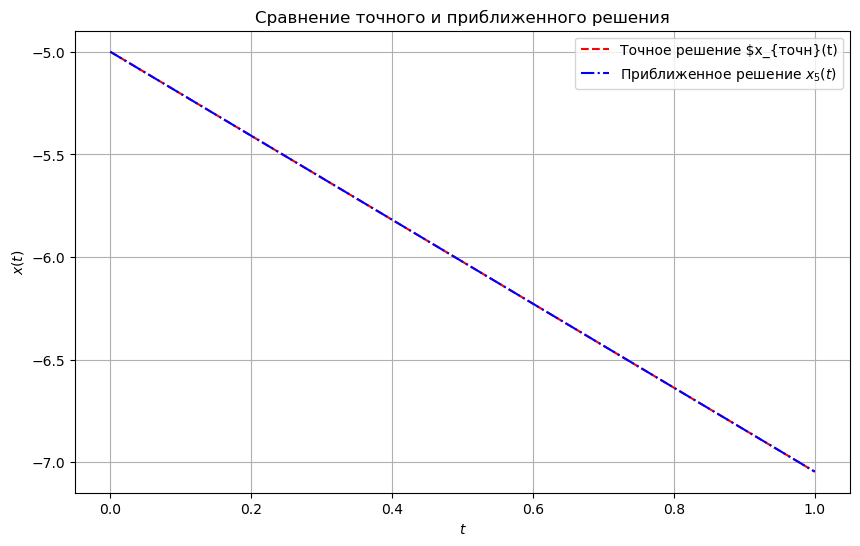

In [17]:
def exact_solution(t, lam):
    C = (-5.0 * np.log(2)) / (1.0 - lam * (1.0 - np.log(2)))
    return -5.0 + lam * t * C

x_final_exact = exact_solution(t_grid, lambda_0)
actual_error = np.max(np.abs(x_curr - x_final_exact))

print(f"\n--- Результаты ---")
print(f"Фактическая ошибка (||x_N - x_точн||_inf): {actual_error:.8f}")

plt.figure(figsize=(10, 6))
plt.plot(t_grid, x_final_exact, label='Точное решение $x_{точн}(t)', color='red', linestyle='--')
plt.plot(t_grid, x_curr, label=f'Приближенное решение $x_{n}(t)$', color='blue', linestyle='-.')

plt.title('Сравнение точного и приближенного решения')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.legend()
plt.grid(True)
plt.show()
